Imports & globale Einstellungen

In [1]:
import kagglehub
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

ModuleNotFoundError: No module named 'kagglehub'

Dataset laden

In [ ]:
path = kagglehub.dataset_download("harlfoxem/housesalesprediction")
print("Path to dataset files:", path)

csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))
print(f"Dataset geladen: {df.shape[0]} Zeilen, {df.shape[1]} Spalten")

100%|██████████| 780k/780k [00:00<00:00, 88.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/harlfoxem/housesalesprediction/versions/1
Dataset geladen: 21613 Zeilen, 21 Spalten


Feature Engineering - aus bestehenden Features neue Features extrahieren

In [ ]:
path = kagglehub.dataset_download("harlfoxem/housesalesprediction")
print("Path to dataset files:", path)

csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))
print(f"Dataset geladen: {df.shape[0]} Zeilen, {df.shape[1]} Spalten")

# Seattle Zentrum Koordinaten (Spaceneedle)
seattle_lat = 47.6062
seattle_long = -122.3321
# Haus Distanz zum Zentrum
df['distance_to_center'] = np.sqrt((df['lat'] - seattle_lat)**2 + (df['long'] - seattle_long)**2)

# Preis pro sqft_living
df['price_per_sqft_living'] = df['price'] / df['sqft_living']
# Preis pro sqft_lot
df['price_per_sqft_lot'] = df['price'] / df['sqft_lot']

# Schlafzimmer pro sqft_living
df['bedrooms_per_sqft_living'] = df['bedrooms'] / df['sqft_living']
# Badezimmer pro sqft_living
df['bathrooms_per_sqft_living'] = df['bathrooms'] / df['sqft_living']

# Keller erkennen
df['has_basement'] = df['sqft_basement'].apply(lambda x: 1 if x > 0 else 0)

# Alter des Hauses zum Zeitpunkt 2015
df['house_age'] = 2015 - df['yr_built']

# Renovierungen erkennen
df['is_renovated'] = df['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)
# Zeit seit Renovierung
df['years_since_renovation'] = df.apply(lambda row: 2015 - row['yr_renovated'] if row['yr_renovated'] > 0 else row['house_age'], axis=1)

# Durchschnittliche Raum größe
df['avg_room_size'] = df['sqft_living'] / (df['bedrooms'] + df['bathrooms'] + 1)

# Garten Berechnen
df['yard_space_approx'] = df['sqft_lot'] - (df['sqft_living'] / df['floors'])
# Vermeidung negativer Werte beim Garten
df['yard_space_approx'] = df['yard_space_approx'].apply(lambda x: x if x > 0 else 0)

# Luxus score
df['luxury_score'] = (df['grade'] / 13) + (df['condition'] / 5) + (df['waterfront']) + (df['view'] / 4)

# Koordinaten zu einer Grid-Zelle verknüpfen
df['grid_cell_id'] = df['lat'].round(2).astype(str) + "_" + df['long'].round(2).astype(str)
# Text-String label-encoden
df['grid_cell_id'] = df['grid_cell_id'].astype('category').cat.codes


display(df.head())



Using Colab cache for faster access to the 'housesalesprediction' dataset.
Path to dataset files: /kaggle/input/housesalesprediction
Dataset geladen: 21613 Zeilen, 21 Spalten


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,bedrooms_per_sqft_living,bathrooms_per_sqft_living,has_basement,house_age,is_renovated,years_since_renovation,avg_room_size,yard_space_approx,luxury_score,grid_cell_id
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,0.002542,0.000847,0,60,0,60,236.0,4470.0,1.138462,886
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,0.001167,0.000875,1,64,1,24,411.2,5957.0,1.138462,1710
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,0.002597,0.001299,0,82,0,82,192.5,9230.0,1.061538,1779
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,0.002041,0.001531,1,50,0,50,245.0,3040.0,1.538462,934
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,0.001786,0.001190,0,28,0,28,280.0,6400.0,1.215385,1307


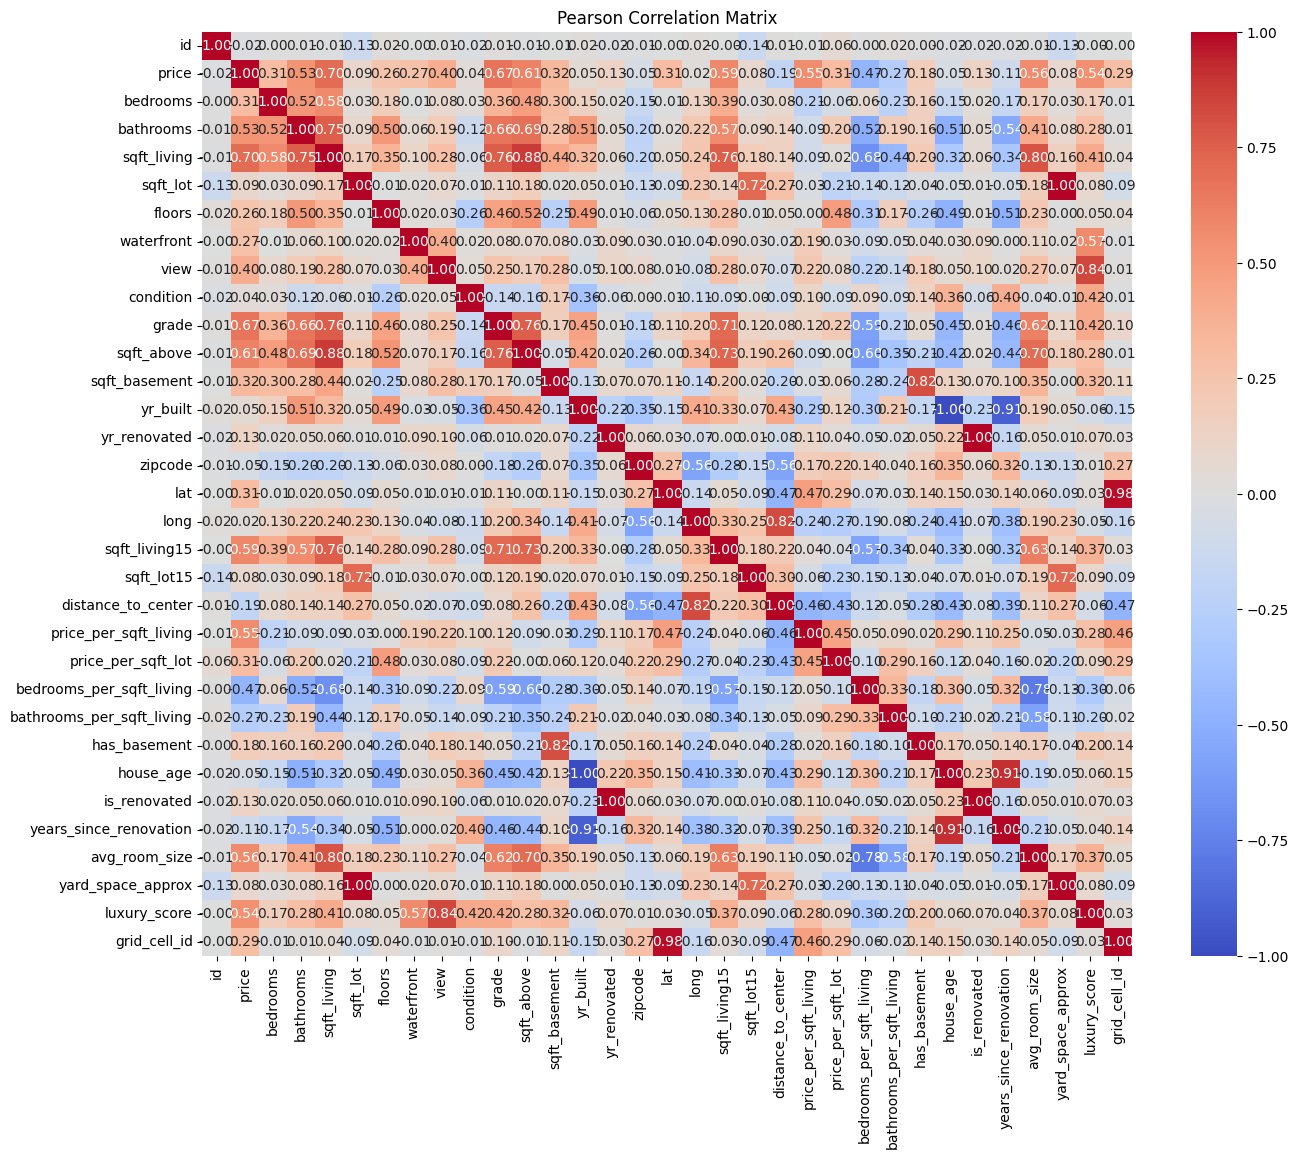

Dataset geladen: 21613 Zeilen, 34 Spalten


In [ ]:
# Calculate the Pearson correlation matrix
corr_matrix = df.corr(method='pearson', numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(15, 12)) # Increased figure size
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Pearson Correlation Matrix')
plt.show()
print(f"Dataset geladen: {df.shape[0]} Zeilen, {df.shape[1]} Spalten")

In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,21613.0,NaN,NaN,NaN,4580301520.864988,2876565571.312049,1000102.0,2123049194.0,3904930410.0,7308900445.0,9900000190.0
date,21613,372,20140623T000000,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,21613.0,NaN,NaN,NaN,540088.141767,367127.196483,75000.0,321950.0,450000.0,645000.0,7700000.0
bedrooms,21613.0,NaN,NaN,NaN,3.370842,0.930062,0.0,3.0,3.0,4.0,33.0
bathrooms,21613.0,NaN,NaN,NaN,2.114757,0.770163,0.0,1.75,2.25,2.5,8.0
sqft_living,21613.0,NaN,NaN,NaN,2079.899736,918.440897,290.0,1427.0,1910.0,2550.0,13540.0
sqft_lot,21613.0,NaN,NaN,NaN,15106.967566,41420.511515,520.0,5040.0,7618.0,10688.0,1651359.0
floors,21613.0,NaN,NaN,NaN,1.494309,0.539989,1.0,1.0,1.5,2.0,3.5
waterfront,21613.0,NaN,NaN,NaN,0.007542,0.086517,0.0,0.0,0.0,0.0,1.0
view,21613.0,NaN,NaN,NaN,0.234303,0.766318,0.0,0.0,0.0,0.0,4.0


Dimensionality Reduction - uninteressante Features entfernen

In [ ]:
interesting_features = ["price", "sqft_living", "bedrooms", "bathrooms", "grade", "waterfront", "sqft_lot", "zipcode"]

df = df[interesting_features]

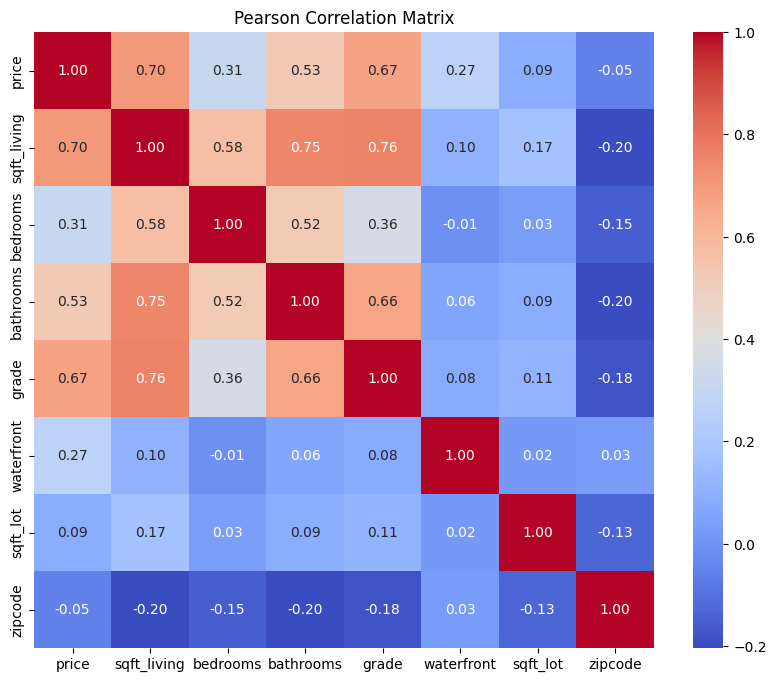

In [ ]:
# Calculate the Pearson correlation matrix
corr_matrix = df.corr(method='pearson')

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Pearson Correlation Matrix')
plt.show()

Data Cleaning - Duplikate entfernen und Fehler handeln

 Noise / verdeckte Fehlwerte (Folie 16 + 19)

In [ ]:
interesting_features = ["price", "sqft_living", "bedrooms", "bathrooms", "grade", "waterfront", "sqft_lot", "zipcode"]

rep = pd.DataFrame({
    "zeros": [(df[c]==0).sum() for c in interesting_features],
    "zeros_%": [round((df[c]==0).mean()*100,1) for c in interesting_features],
    "min": [df[c].min() for c in interesting_features],
    "max": [df[c].max() for c in interesting_features],
}, index=interesting_features)
rep

,zeros,zeros_%,min,max
price,0,0.0,75000.0,7700000.0
sqft_living,0,0.0,290.0,13540.0
bedrooms,13,0.1,0.0,33.0
bathrooms,10,0.0,0.0,8.0
grade,0,0.0,1.0,13.0
waterfront,21450,99.2,0.0,1.0
sqft_lot,0,0.0,520.0,1651359.0
zipcode,0,0.0,98001.0,98199.0


Boxplots unserer ausgewählten Features

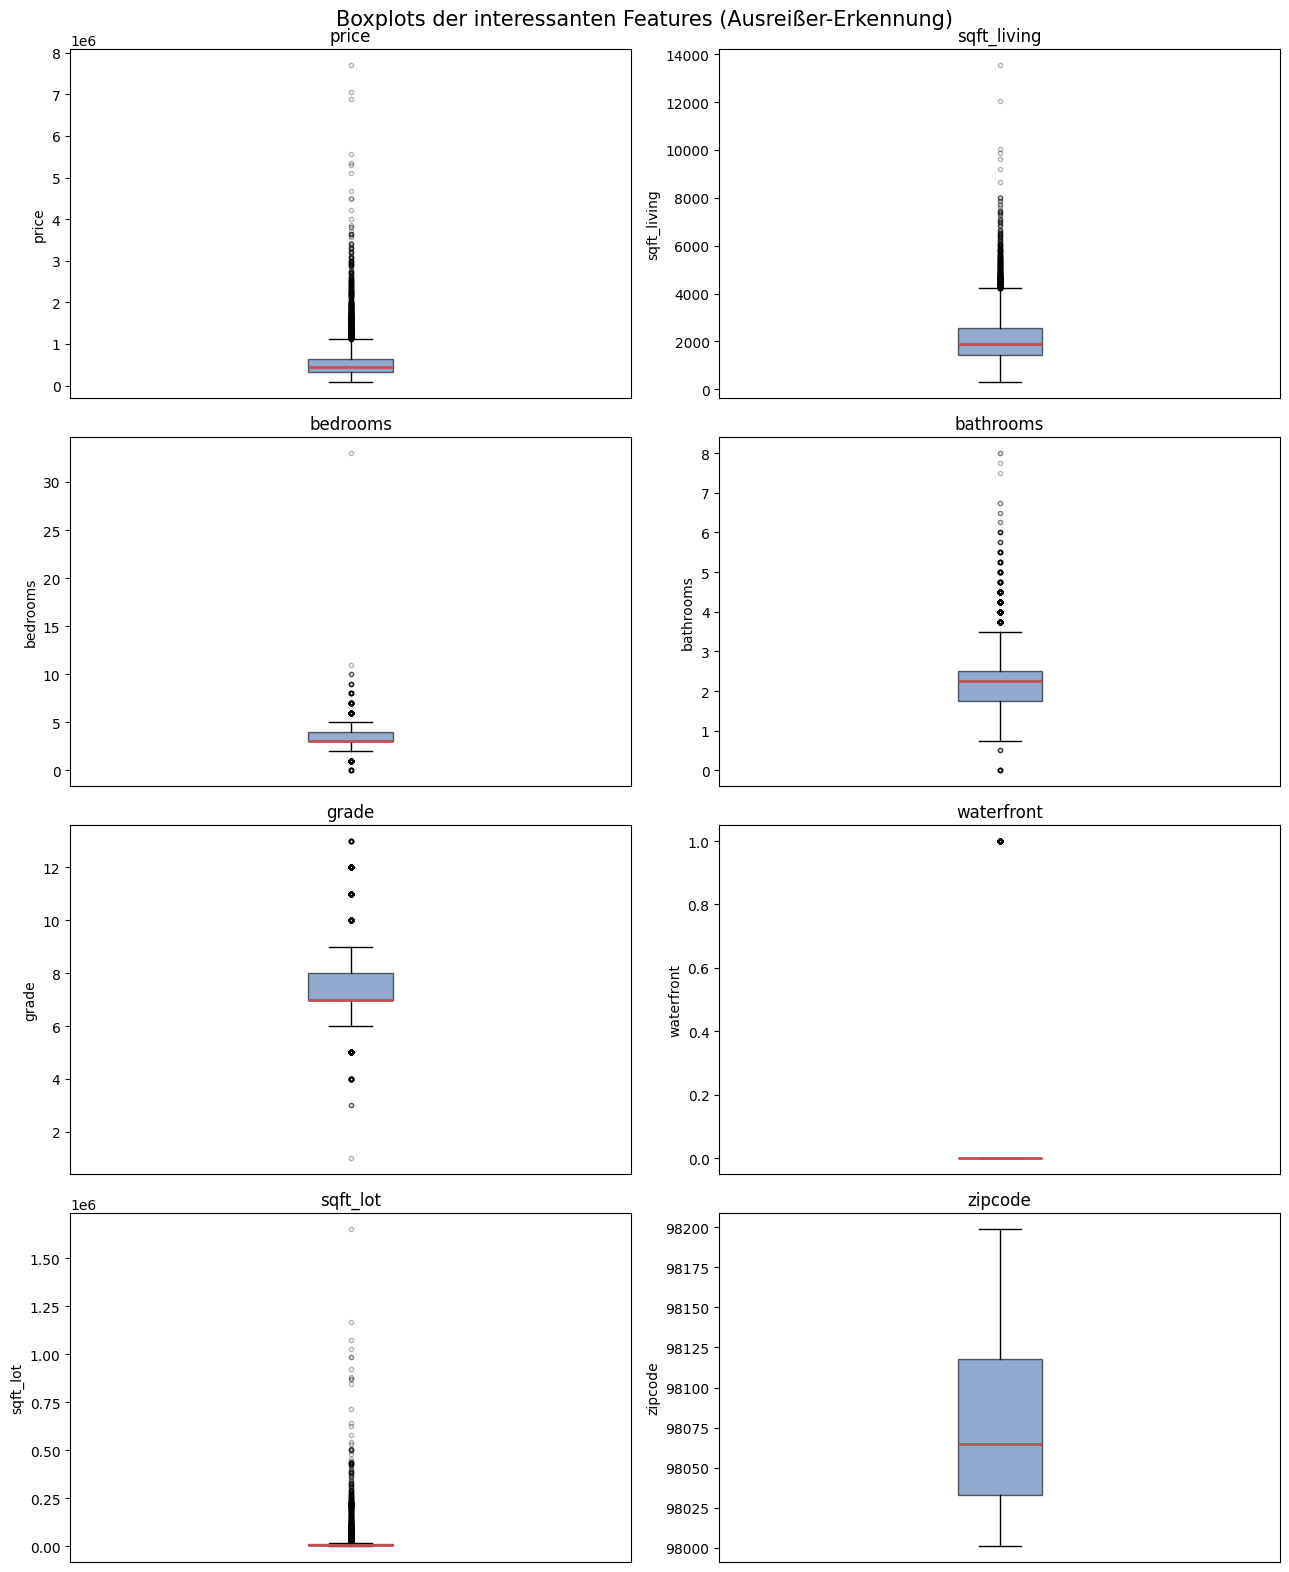

In [ ]:
interesting_features = ["price", "sqft_living", "bedrooms", "bathrooms",
                        "grade", "waterfront", "sqft_lot", "zipcode"]

fig, axes = plt.subplots(4, 2, figsize=(13, 16))
axes = axes.ravel()
for ax, feat in zip(axes, interesting_features):
    ax.boxplot(df[feat], vert=True, patch_artist=True,
               boxprops=dict(facecolor="#4C72B0", alpha=.6),
               medianprops=dict(color="#C44E52", linewidth=2),
               flierprops=dict(marker="o", markersize=3, alpha=.3))
    ax.set_title(feat); ax.set_xticks([]); ax.set_ylabel(feat)

fig.suptitle("Boxplots der interessanten Features (Ausreißer-Erkennung)", fontsize=15)
fig.tight_layout()
plt.show()

Alle Daten laden

In [ ]:
df = pd.read_csv(os.path.join(path, csv_file))

0 Badezimmer

In [ ]:
df.loc[df["bathrooms"] == 0]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
875,6306400140,20140612T000000,1095000.0,0,0.0,3064,4764,3.5,0,2,...,7,3064,0,1990,0,98102,47.6362,-122.322,2360,4000
1149,3421079032,20150217T000000,75000.0,1,0.0,670,43377,1.0,0,0,...,3,670,0,1966,0,98022,47.2638,-121.906,1160,42882
3119,3918400017,20150205T000000,380000.0,0,0.0,1470,979,3.0,0,2,...,8,1470,0,2006,0,98133,47.7145,-122.356,1470,1399
5832,5702500050,20141104T000000,280000.0,1,0.0,600,24501,1.0,0,0,...,3,600,0,1950,0,98045,47.5316,-121.749,990,22549
6994,2954400190,20140624T000000,1295650.0,0,0.0,4810,28008,2.0,0,0,...,12,4810,0,1990,0,98053,47.6642,-122.069,4740,35061
9773,3374500520,20150429T000000,355000.0,0,0.0,2460,8049,2.0,0,0,...,8,2460,0,1990,0,98031,47.4095,-122.168,2520,8050
9854,7849202190,20141223T000000,235000.0,0,0.0,1470,4800,2.0,0,0,...,7,1470,0,1996,0,98065,47.5265,-121.828,1060,7200
10481,203100435,20140918T000000,484000.0,1,0.0,690,23244,1.0,0,0,...,7,690,0,1948,0,98053,47.6429,-121.955,1690,19290
14423,9543000205,20150413T000000,139950.0,0,0.0,844,4269,1.0,0,0,...,7,844,0,1913,0,98001,47.2781,-122.250,1380,9600
19452,3980300371,20140926T000000,142000.0,0,0.0,290,20875,1.0,0,0,...,1,290,0,1963,0,98024,47.5308,-121.888,1620,22850


33 Badezimmer

In [ ]:
df.loc[df["bedrooms"] == 33]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
15870,2402100895,20140625T000000,640000.0,33,1.75,1620,6000,1.0,0,0,...,7,1040,580,1947,0,98103,47.6878,-122.331,1330,4700


Attribute Transformation

In [ ]:
# Applying log transformation to handle skewness
columns_to_transform = ['price', 'sqft_living', 'sqft_lot']

for col in columns_to_transform:
    df[col] = np.log1p(df[col])

print("Log transformation complete. Updated sample:")
df[columns_to_transform].head()

Log transformation complete. Updated sample:


,price,sqft_living,sqft_lot
0,12.309987,7.074117,8.639588
1,13.195616,7.852050,8.887791
2,12.100718,6.647688,9.210440
3,13.311331,7.581210,8.517393
4,13.142168,7.427144,8.997271


In [ ]:
# Identify columns to scale (all except 'waterfront')
features_to_scale = [col for col in df.columns if col not in ['waterfront', 'zipcode']]

scaler = StandardScaler()
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("Z-transformation complete. Updated statistics for scaled columns:")
display(df[features_to_scale].describe().loc[['mean', 'std']])
display(df.head())

Z-transformation complete. Updated statistics for scaled columns:


,price,sqft_living,bedrooms,bathrooms,grade,sqft_lot
mean,4.878755e-15,5.102310e-16,2.367051e-16,-1.788439e-16,2.524855e-16,-2.419652e-16
std,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00


,price,sqft_living,bedrooms,bathrooms,grade,waterfront,sqft_lot,zipcode
0,-1.400936,-1.123053,-0.398737,-1.447464,-0.558836,0,-0.388517,98178
1,0.280624,0.709313,-0.398737,0.175607,-0.558836,0,-0.113429,98125
2,-1.798279,-2.127474,-1.473959,-1.447464,-1.409587,0,0.244170,98028
3,0.500335,0.071368,0.676485,1.149449,-0.558836,0,-0.523948,98136
4,0.179141,-0.291522,-0.398737,-0.149007,0.291916,0,0.007910,98074
